In [56]:
import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt

from tuner import Tuner

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [61]:
svd = pd.read_csv('../../pickle-object/balance_final_svd_table.csv')

In [64]:
svd

,name,description_x,SV_1,SV_2,SV_3,SV_4,SV_5,SV_6,SV_7,SV_8,...,SV_709,SV_710,SV_711,SV_712,SV_713,SV_714,SV_715,SV_716,SV_717,SV_718
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,0.049594,0.259442,-0.325072,0.124995,0.369973,0.176221,0.000246,0.007431,...,0.000059,-0.000132,-0.000136,0.000233,-0.000074,-0.000063,0.000200,-0.000019,-0.000068,-0.000133
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",0.039517,0.165516,-0.154951,0.029922,-0.183830,-0.024334,-0.456220,0.816265,...,0.000063,0.000066,-0.000041,0.000069,0.000169,-0.000038,0.000340,-0.000054,0.000117,-0.000245
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,0.049594,0.259442,-0.325072,0.124995,0.369973,0.176221,0.000246,0.007431,...,0.000059,-0.000132,-0.000136,0.000233,-0.000074,-0.000063,0.000200,-0.000019,-0.000068,-0.000133
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,0.049594,0.259442,-0.325072,0.124995,0.369973,0.176221,0.000246,0.007431,...,0.000059,-0.000132,-0.000136,0.000233,-0.000074,-0.000063,0.000200,-0.000019,-0.000068,-0.000133
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",0.039517,0.165516,-0.154951,0.029922,-0.183830,-0.024334,-0.456220,0.816265,...,0.000063,0.000066,-0.000041,0.000069,0.000169,-0.000038,0.000340,-0.000054,0.000117,-0.000245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8188,Malhya: Lands of Legends,With the balance of the planet Malhya threaten...,0.016836,0.483974,0.153830,-0.852556,0.043001,-0.055082,0.008114,-0.022958,...,-0.000048,-0.000097,-0.000194,-0.000082,0.000177,-0.000100,-0.000022,0.000052,0.000047,0.000113
8189,Malhya: Lands of Legends,With the balance of the planet Malhya threaten...,0.016836,0.483974,0.153830,-0.852556,0.043001,-0.055082,0.008114,-0.022958,...,-0.000048,-0.000097,-0.000194,-0.000082,0.000177,-0.000100,-0.000022,0.000052,0.000047,0.000113
8190,Erune,Enter the world of Erune and roam through its ...,0.044925,0.645854,0.640907,0.407648,0.013686,-0.035358,0.011637,-0.008194,...,0.000015,-0.000099,0.000066,0.000090,-0.000066,0.000043,0.000071,0.000003,0.000055,0.000044
8191,Erune,Enter the world of Erune and roam through its ...,0.044925,0.645854,0.640907,0.407648,0.013686,-0.035358,0.011637,-0.008194,...,0.000015,-0.000099,0.000066,0.000090,-0.000066,0.000043,0.000071,0.000003,0.000055,0.000044


In [62]:
X = svd.iloc[:, 6:]

In [63]:
y = svd['class']

KeyError: 'class'

In [19]:
y_baseline = np.full_like(round(y), fill_value=np.mean(round(y)))
rmse_baseline = np.sqrt(mean_squared_error(round(y), round(pd.Series(data=y_baseline))))
rmse_baseline

np.float64(2.9154759474226504)

In [37]:
y_baseline = np.full_like(y, fill_value=np.mean(y))
rmse_baseline = np.sqrt(mean_squared_error(y, y_baseline))
rmse_baseline

np.float64(2.9154759474226504)

In [38]:
tuner = Tuner(X, y)

In [39]:
def bin_score(X, y, model, mapping_fn=round):
    """
    Evaluate a regression model, then bin outputs for classification-style accuracy.

    Parameters:
    -----------
    X : array-like
        Features
    y : array-like
        True continuous targets
    model : sklearn-like model
        Must implement .fit() and .predict()
    mapping_fn : function
        Function that maps continuous values → categorical bins
        Should work on numpy arrays

    Returns:
    --------
    dict with:
        - accuracy
        - mae
        - rmse
    """
    y_pred = model.predict(X)

    y_binned = y.apply(mapping_fn)
    y_pred_binned = pd.Series(y_pred).apply(mapping_fn)
    
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    return float(rmse)

# KNN Regressor

In [40]:
tuner.tune(KNeighborsRegressor,
           10,
           0.25,
           'n_neighbors',
           range(1,15),
           {},
           bin_score,
           True
          )

In [45]:
tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,test_score,train_score
0,17779785167,KNeighborsRegressor,n_neighbors,2,0.507077,0.958088


In [53]:
tuner.trains[17779785167]

,1,2,3,4,5,6,7,8,9,10
0,0.065320,0.061101,0.078316,0.071181,0.069282,0.063246,0.071181,0.074833,0.071181,0.084853
1,0.521600,0.512055,0.504050,0.492747,0.521280,0.508658,0.497125,0.501730,0.511794,0.499733
2,0.651608,0.643601,0.648965,0.632456,0.654036,0.638076,0.638540,0.643716,0.653084,0.623681
3,0.729200,0.725063,0.728732,0.702057,0.721133,0.714248,0.720706,0.729726,0.724488,0.705668
4,0.778388,0.780133,0.792929,0.765426,0.772363,0.774672,0.786303,0.784088,0.788071,0.771278
5,0.826640,0.828139,0.839206,0.814280,0.818300,0.818960,0.835477,0.835495,0.823718,0.823444
6,0.860811,0.866743,0.876157,0.859416,0.859004,0.856721,0.874799,0.868600,0.861892,0.863377
7,0.895821,0.901737,0.913455,0.895412,0.894935,0.889733,0.908403,0.898508,0.898893,0.894965
8,0.926813,0.935695,0.943568,0.922071,0.925119,0.922557,0.931829,0.927598,0.927509,0.925311
9,0.958067,0.961879,0.974086,0.960143,0.956070,0.949401,0.963263,0.958924,0.956712,0.956354


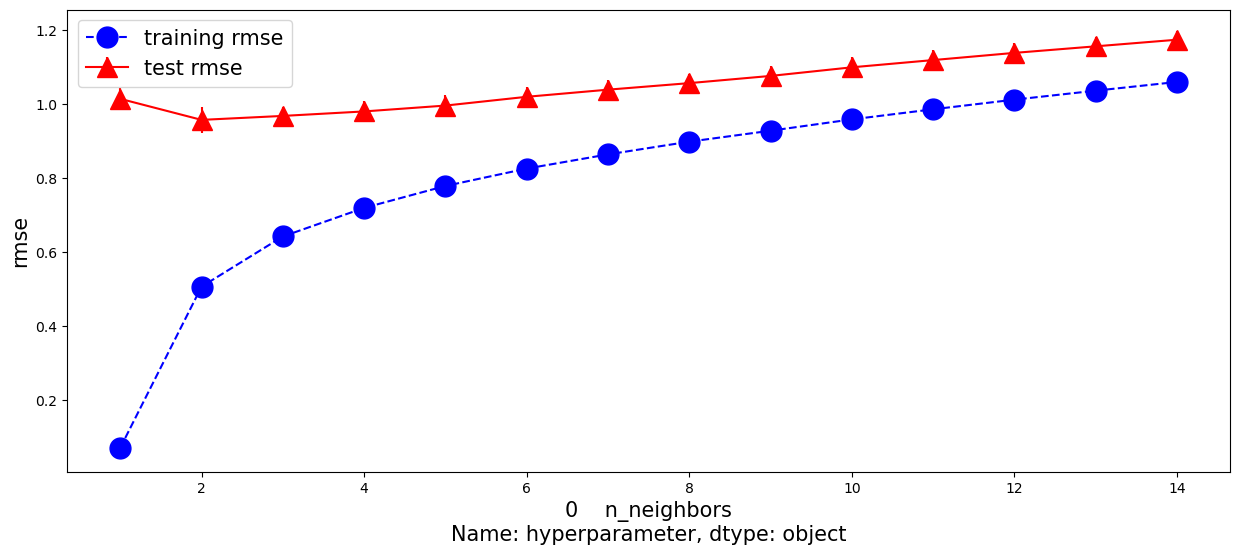

In [47]:
tuner.plot_hyperparameter_tuning(17779785167, metric_name='rmse')

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [54]:
knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [55]:
knn_y_pred = knn_reg.predict(X_test)

In [59]:
def build_conf_matrix(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(round(y_test), round(pd.Series(data=y_pred)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[i for i in range(1,11)])
    disp.plot(cmap=plt.cm.Blues)
    pass

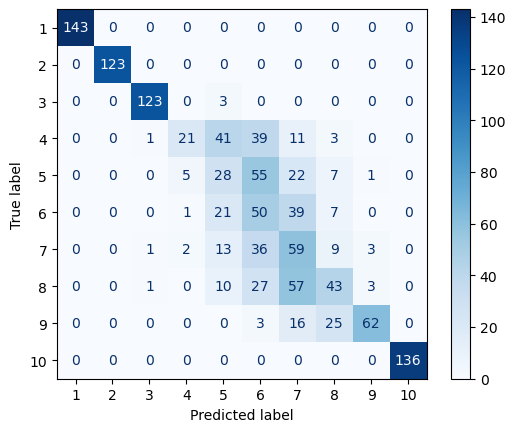

In [57]:
cm = confusion_matrix(round(y_test), round(pd.Series(data=knn_y_pred)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[i for i in range(1,11)])
disp.plot(cmap=plt.cm.Blues)

In [58]:
from sklearn.linear_model import Lasso

In [60]:
lasso_params = [1e-5, 1e-4, 1e-3,
                7e-3, 1e-2, 5e-2,
                0.1, 0.2, 0.4,
                0.75, 1, 1.5,
                3, 10, 20,
                100, 500]
tuner.tune(Lasso,
           10,
           0.25,
           'alpha',
           lasso_params,
           {'max_iter': 100000},
           bin_score,
           True)

KeyboardInterrupt: 

In [55]:
tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,test_score,train_score
0,17778267156,KNeighborsRegressor,n_neighbors,10.0000,0.83907,0.934097
1,17778347950,Lasso,alpha,0.0001,0.78636,0.869881


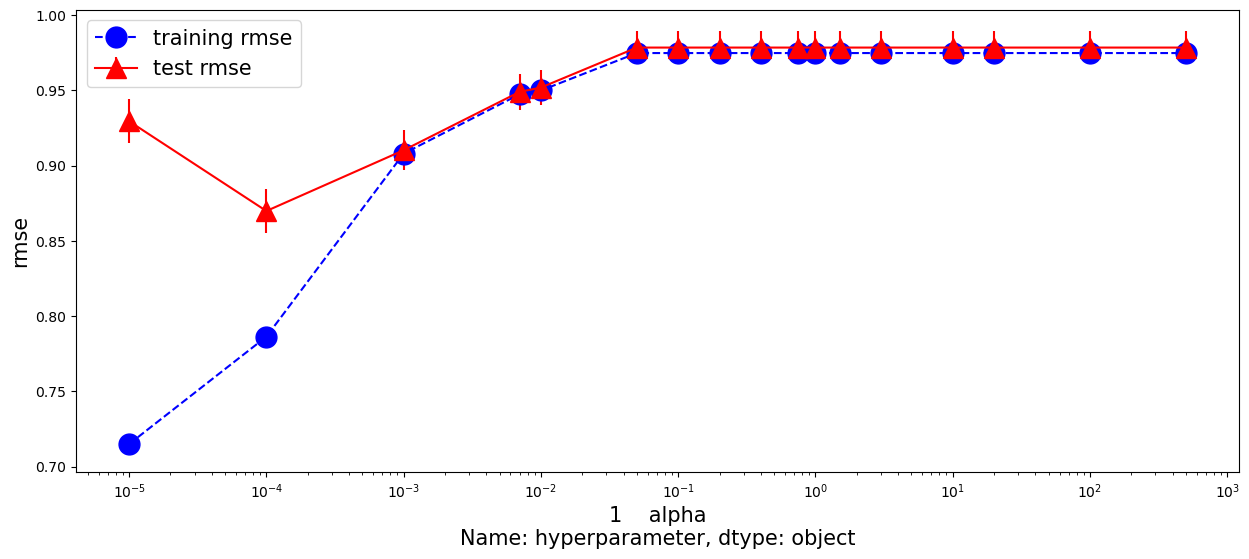

In [57]:
tuner.plot_hyperparameter_tuning(17778347950, True, metric_name='rmse')

In [67]:
from sklearn.ensemble import RandomForestRegressor

In [68]:
rfr_settings = {}

In [ ]:
tuner.tune(RandomForestRegressor,
           10,
           0.25,
           'max_depth',
           range(2,6),
           {'random_state': 42},
           bin_score,
           True)

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

In [70]:
tuner.tune(GradientBoostingRegressor,
           10,
           0.25,
           'max_depth',
           range(2,6),
           {'random_state': 42},
           bin_score,
           True)

In [72]:
tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,test_score,train_score
0,17778267156,KNeighborsRegressor,n_neighbors,10.0000,0.839070,0.934097
1,17778347950,Lasso,alpha,0.0001,0.786360,0.869881
2,17779454294,GradientBoostingRegressor,max_depth,5.0000,0.637405,0.898990


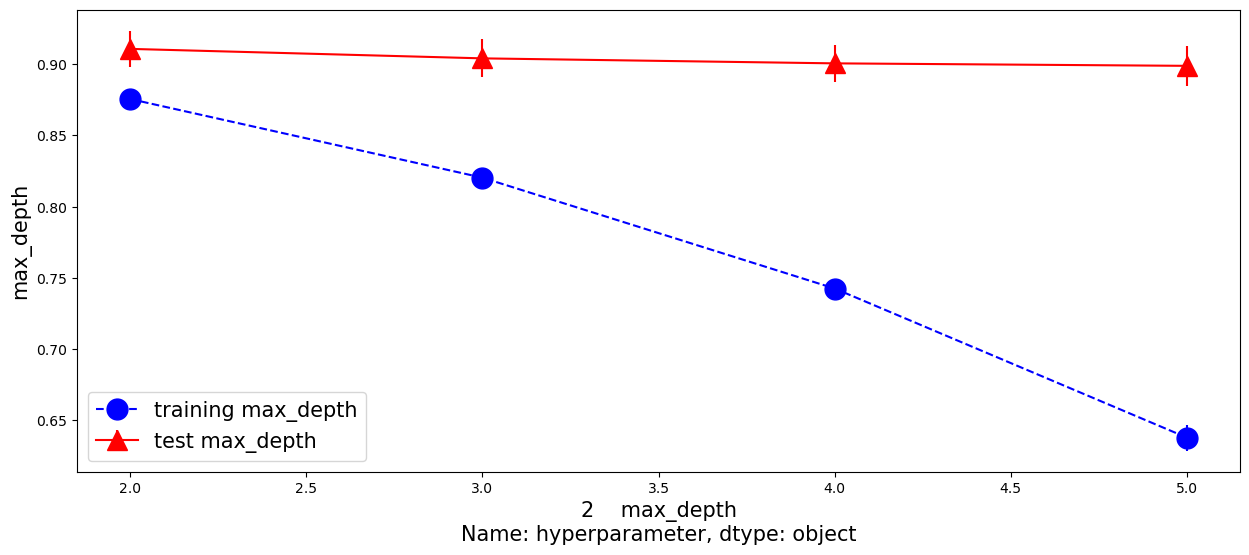

In [73]:
tuner.plot_hyperparameter_tuning(17779454294, metric_name='max_depth')

In [ ]:
tuner.tune(GradientBoostingRegressor,
           10,
           0.25,
           'learning_rate',
           [1e-3, 1e-2, 1e-1],
           {'random_state': 42, 'max_depth': 5},
           bin_score,
           True)